In [2]:
#Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio

In [6]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
# remove hidden spaces
df.columns = df.columns.str.strip()  

 # paste the output here
print(df.columns.tolist())  


['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

Start Data Cleaning & Validation

In [10]:
#to change the format
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)

In [11]:
#Convert Date Columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
#Create Shipping Lead Time  ,:Shipping Lead Time=Ship Date−Order Date
df['Lead Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [13]:
filtered_df = df.copy()

In [14]:
# KPI
delay_frequency = (
    (filtered_df['Lead Time'] > 7)
    .mean() * 100
)

print(delay_frequency)

100.0


In [15]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
Lead Time         0
dtype: int64

In [16]:
#Remove rows with critical missing values:
df = df.dropna(subset=[
    'Ship Date',
    'Order Date',
    'State/Province',
    'Region',
    'Ship Mode'
])

In [17]:
#Standardize Text Columns
text_cols = [
    'City',
    'State/Province',
    'Region',
    'Division',
    'Ship Mode'
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

Create Factory Mapping

In [18]:
factory_df = pd.DataFrame({
    'Factory': [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    
    'Latitude': [
        32.881893,
        32.076176,
        48.11914,
        41.446333,
        35.1175
    ],
    
    'Longitude': [
        -111.768036,
        -81.088371,
        -96.18115,
        -90.565487,
        -89.971107
    ]
})

Product-to-Factory Mapping

In [19]:
product_factory = {
    
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    
    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    
    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

In [20]:
#Add Factory Column
df['Factory'] = df['Product Name'].map(product_factory)

In [21]:
#Check missing factories:
df['Factory'].isnull().sum()

np.int64(0)

Create Route Definitions

In [ ]:
#Factory (State Route)
df['Factory_State_Route'] = (
    df['Factory'] + " → " + df['State/Province']
)

#Factory (Region Route)
df['Factory_Region_Route'] = (
    df['Factory'] + " → " + df['Region']
)

KPI Calculations

In [23]:
#Average Lead Time
avg_lead_time = df['Lead Time'].mean()

print(avg_lead_time)

1320.8418677653522


In [24]:
#Delay Threshold
#Suppose delay threshold = 7 days
delay_threshold = 7

In [25]:
#Delay Frequency

df['Delayed'] = np.where(
    df['Lead Time'] > delay_threshold,
    1,
    0
)

delay_frequency = (
    df['Delayed'].mean() * 100
)

print(delay_frequency)

100.0


Route-Level Aggregation

In [26]:
#Aggregate Route Metrics
route_analysis = df.groupby(
    'Factory_State_Route'
).agg({

    'Lead Time': [
        'count',
        'mean',
        'std',
        'max'
    ],

    'Sales': 'sum',

    'Gross Profit': 'sum'
})

In [27]:
#Flatten Column Names
route_analysis.columns = [
    'Total Shipments',
    'Avg Lead Time',
    'Lead Time Std',
    'Max Lead Time',
    'Total Sales',
    'Total Profit'
]

route_analysis = route_analysis.reset_index()

Create Route Efficiency Score

In [34]:
min_lt = route_analysis['Avg Lead Time'].min()
max_lt = route_analysis['Avg Lead Time'].max()

route_analysis['Efficiency Score'] = 100 - (
    (
        route_analysis['Avg Lead Time'] - min_lt
    ) / (
        max_lt - min_lt
    )
) * 100

Rank Best & Worst Routes

In [35]:
#top-10
top_routes = route_analysis.sort_values(
    by='Efficiency Score',
    ascending=False
).head(10)

print(top_routes)

                 Factory_State_Route  Total Shipments  Avg Lead Time  \
80       Secret Factory → New Mexico                2          906.0   
76         Secret Factory → Nebraska                1          906.0   
121    The Other Factory → Louisiana                1          907.0   
115  The Other Factory → Connecticut                2          907.5   
75      Secret Factory → Mississippi                1          908.0   
158          Wicked Choccy's → Maine                2          908.0   
70        Secret Factory → Louisiana                2          908.5   
74        Secret Factory → Minnesota                1          909.0   
64         Secret Factory → Delaware                1          909.0   
88   Secret Factory → South Carolina                1          909.0   

     Lead Time Std  Max Lead Time  Total Sales  Total Profit  Efficiency Score  
80        2.828427            908        12.50          6.50        100.000000  
76             NaN            906         2.5

In [36]:
#bottom-10
bottom_routes = route_analysis.sort_values(
    by='Efficiency Score'
).head(10)

print(bottom_routes)


                 Factory_State_Route  Total Shipments  Avg Lead Time  \
103         Sugar Shack → New Jersey                1         1642.0   
78    Secret Factory → New Hampshire                1         1641.0   
98         Sugar Shack → Connecticut                1         1641.0   
194  Wicked Choccy's → West Virginia                2         1639.0   
37      Lot's O' Nuts → North Dakota                5         1638.2   
63      Secret Factory → Connecticut                1         1638.0   
125       The Other Factory → Nevada                1         1638.0   
110         Sugar Shack → Washington                1         1638.0   
97          Sugar Shack → California                1         1638.0   
105               Sugar Shack → Ohio                2         1637.5   

     Lead Time Std  Max Lead Time  Total Sales  Total Profit  Efficiency Score  
103            NaN           1642         5.97          3.72          0.000000  
78             NaN           1641         6.2

Geographic Bottleneck Analysis

In [37]:
#Region-Level Performance
region_analysis = df.groupby('Region').agg({

    'Lead Time': [
        'mean',
        'count',
        'std'
    ],

    'Sales': 'sum'
})

region_analysis.columns = [
    'Avg Lead Time',
    'Shipment Volume',
    'Lead Time Variability',
    'Sales'
]

region_analysis = region_analysis.reset_index()

In [ ]:
#Detect Bottleneck Regions
#High lead time + high shipment volume.
bottlenecks = region_analysis[
    (region_analysis['Avg Lead Time'] > 6) &
    (region_analysis['Shipment Volume'] > 100)
]

print(bottlenecks)

     Region  Avg Lead Time  Shipment Volume  Lead Time Variability     Sales
0  Atlantic    1322.745144             2986             256.541810  41197.24
1      Gulf    1311.374691             1620             264.727855  22247.26
2  Interior    1323.091221             2335             262.693597  32037.60
3   Pacific    1322.194897             3253             266.470647  46301.53


Ship Mode Performance Analysis

In [28]:
#Compare Shipping Modes
ship_mode_analysis = df.groupby(
    'Ship Mode'
).agg({

    'Lead Time': [
        'mean',
        'std',
        'count'
    ],

    'Cost': 'sum',

    'Sales': 'sum'
})

ship_mode_analysis.columns = [
    'Avg Lead Time',
    'Lead Time Std',
    'Shipment Count',
    'Total Cost',
    'Total Sales'
]

ship_mode_analysis = ship_mode_analysis.reset_index()

print(ship_mode_analysis)

        Ship Mode  Avg Lead Time  Lead Time Std  Shipment Count  Total Cost  \
0     First Class    1338.275840     265.632140            1548     7308.30   
1        Same Day    1333.442413     253.813374             547     2412.94   
2    Second Class    1323.845376     261.813569            1979     9553.70   
3  Standard Class    1314.334641     262.400116            6120    29065.89   

   Total Sales  
0     21319.39  
1      7113.67  
2     27860.22  
3     85490.35  


Visualizations

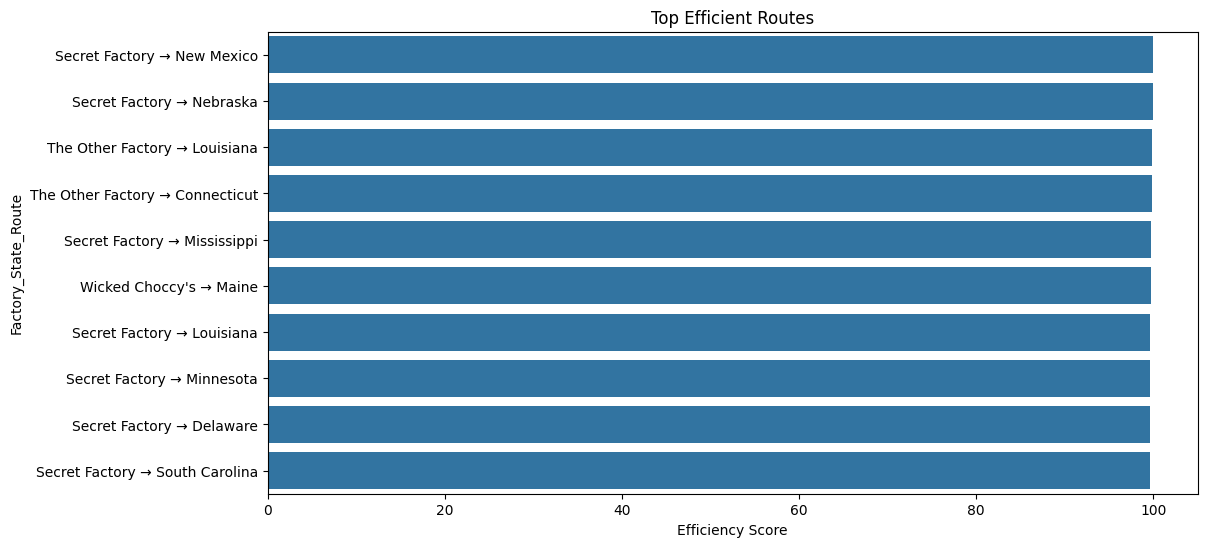

In [37]:
#A. Top Routes Bar Chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_routes,
    x='Efficiency Score',
    y='Factory_State_Route'
)

plt.title("Top Efficient Routes")
plt.show()


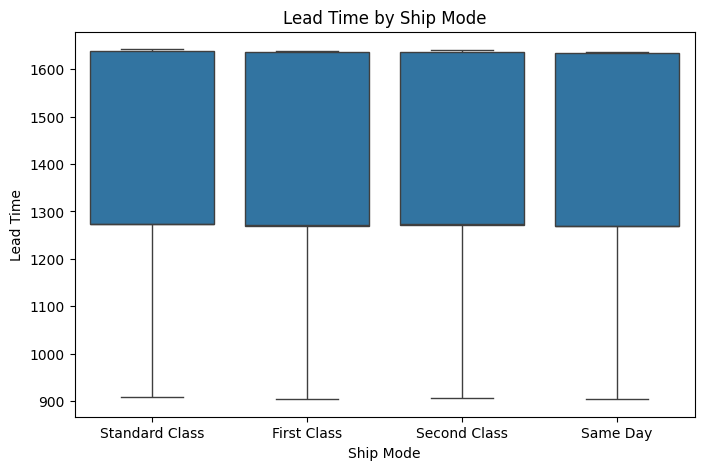

In [38]:
#B. Ship Mode Comparison
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Lead Time'
)

plt.title("Lead Time by Ship Mode")
plt.show()

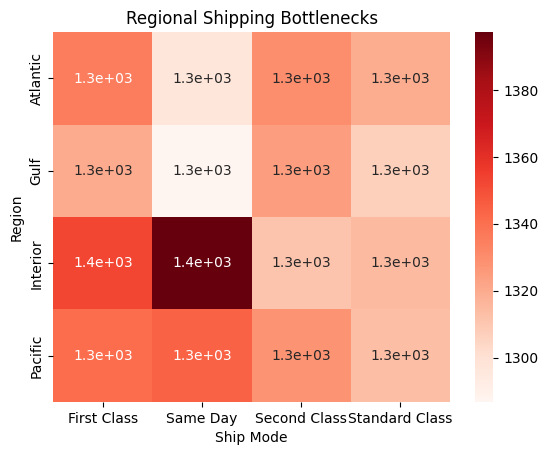

In [40]:
#C. Region Bottleneck Heatmap
pivot_table = df.pivot_table(
    values='Lead Time',
    index='Region',
    columns='Ship Mode',
    aggfunc='mean'
)

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='Reds'
)

plt.title("Regional Shipping Bottlenecks")
plt.show()

Geographic Shipping Map (Plotly)

In [45]:
state_analysis = df.groupby(
    'State/Province'
)['Lead Time'].mean().reset_index()


In [46]:
#INSTALL nbformat
fig = px.choropleth(
    state_analysis,
    locations='State/Province',
    locationmode='USA-states',
    color='Lead Time',
    scope='usa',
    title='US Shipping Lead Time Heatmap'
)

fig.show()

Order-Level Shipment Timeline

In [1]:
sample_orders = df.sort_values(
    by='Lead Time',
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sample_orders,
    x='Order Date',
    y='Lead Time'
)

plt.xticks(rotation=45)

plt.title("Shipment Timeline")
plt.show()

NameError: name 'df' is not defined